In [1]:
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression


font = {"size": 20}
matplotlib.rc("font", **font)
matplotlib.rcParams["text.usetex"] = True

import sys

sys.path.append("../models")
from linear_sscr import LinearSSCR

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Estimated W =  [[0.92746234 0.94822717]]
Estimated S =  [[ 1.0608786 -1.060628 ]]
Estimated beta =  [[0.937793]]
Estimated sigma =  [0.0001153]
Estimated tau =  [9.321228e-05]
Estimated microergodic =  [[0.49987975 0.49999833]]
True microergodic =  [[0.5 0.5]]
Estimated W =  [[-0.8220539 -1.0152591]]
Estimated S =  [[ 0.9928809  -0.99224144]]
Estimated beta =  [[-0.9179138]]
Estimated sigma =  [0.00010692]
Estimated tau =  [8.2004044e-05]
Estimated microergodic =  [[0.49938312 0.49971062]]
True microergodic =  [[0.5 0.5]]
Estimated W =  [[0.96172285 0.9090459 ]]
Estimated S =  [[ 0.9677512  -0.96648186]]
Estimated beta =  [[0.93496716]]
Estimated sigma =  [9.419733e-05]
Estimated tau =  [8.720599e-05]
Estimated microergodic =  [[0.4994321  0.50008655]]
True microergodic =  [[0.5 0.5]]
Estimated W =  [[-1.2150165 -0.9002146]]
Estimated S =  [[-0.99141043  0.98937017]]
Estimated beta =  [[-1.0567671]]
Estimated sigma =  [9.71479e-05]
Estimated tau =  [0.00014693]
Estimated microergodic =

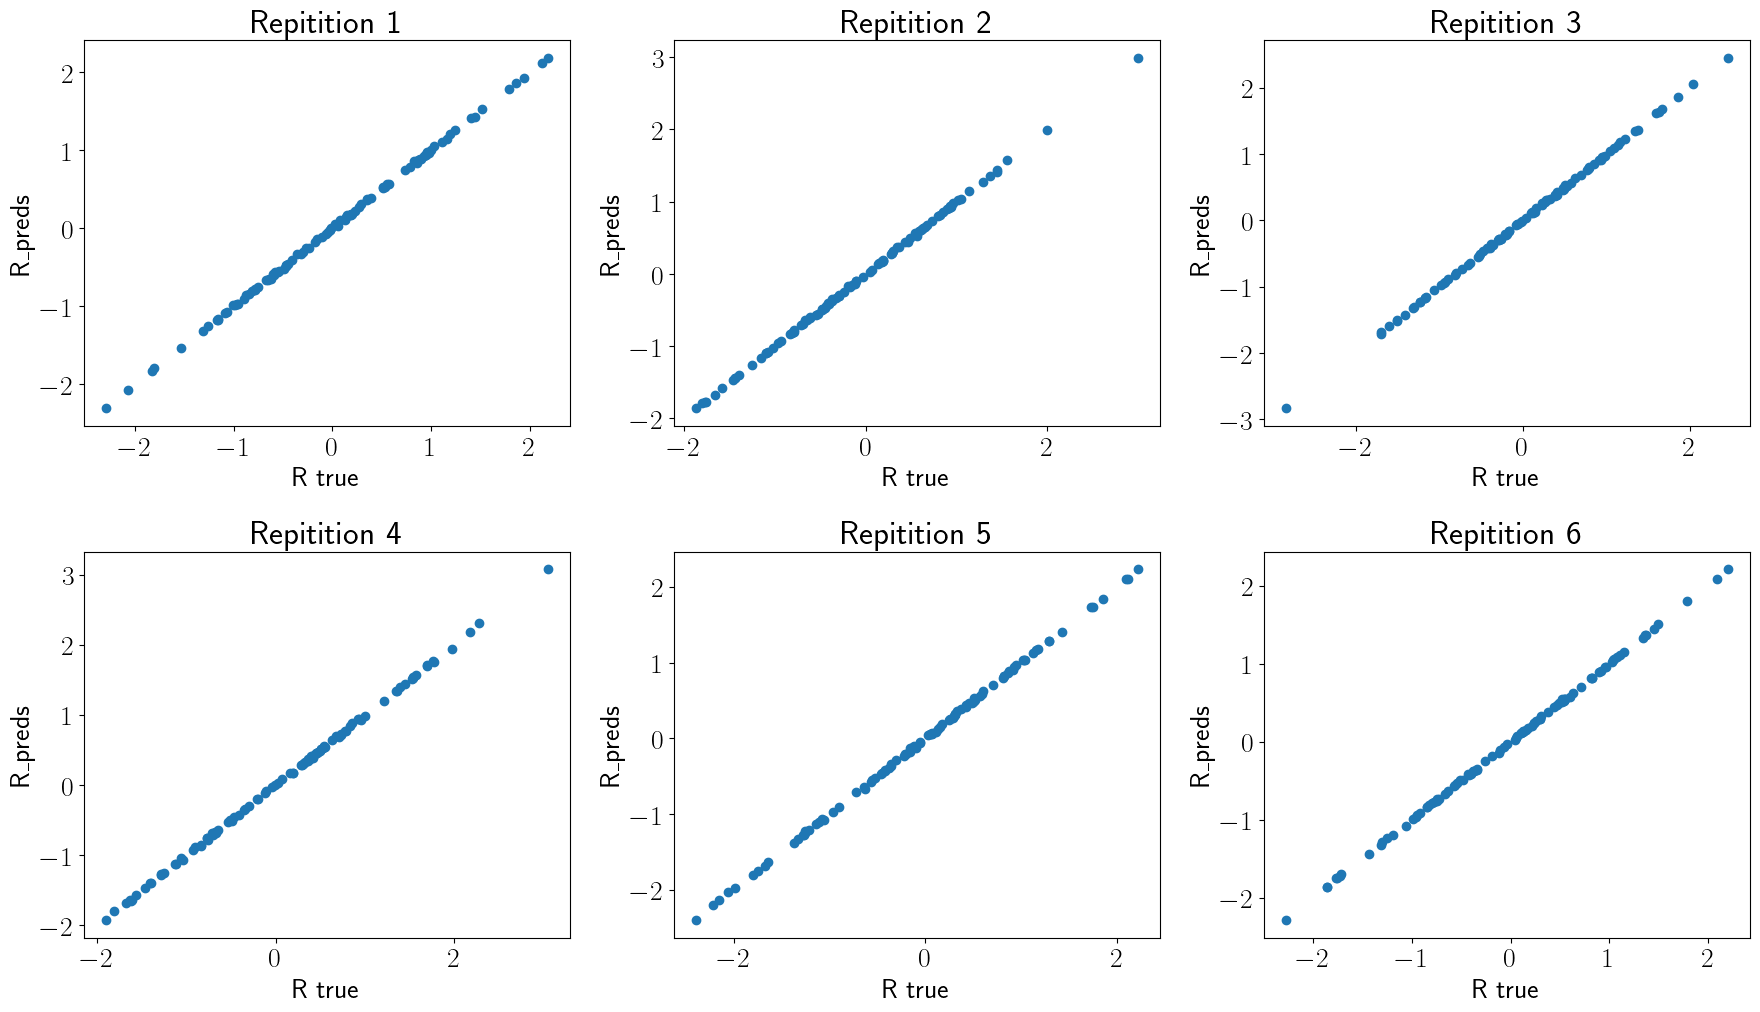

In [3]:

n = 100
m = 150
p = 2
d = 1


n_repititions = 6

# plt.figure(figsize=(7, 5))
plt.figure(figsize=(18, 15))

for ii in range(n_repititions):

    zx = onp.random.normal(size=(n, d))
    zy = onp.random.normal(size=(m, d))
    t = onp.random.normal(size=(n, d))
    W = onp.random.normal(size=(d, p))
    W = onp.array([[1,1]])
    S = onp.random.normal(size=(d, p))
    S = onp.array([[-1,1]])
    beta = onp.random.normal(size=(d, 1))
    beta = onp.array([[1]])
    sigma2 = 1e-2
    tau2 = 1e-2

    X = zx @ S + t @ W + onp.random.normal(scale=sigma2, size=(n, p))
    Y = zy @ S + onp.random.normal(scale=sigma2, size=(m, p))
    R = t @ beta + onp.random.normal(scale=tau2, size=(n, 1))

    model = LinearSSCR()
    model.fit(X, Y, R, d, verbose=False)

    preds = model.predict(X)


    plt.subplot(3, 3, ii + 1)
    plt.title("Repitition {}".format(ii + 1))
    plt.xlabel("R true")
    plt.scatter(R, preds)
    plt.ylabel("R_preds")


plt.tight_layout()
plt.savefig("./out/simulation_example.png")
plt.show()

